In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.ppm_features import ppm_features

warnings.filterwarnings("ignore")

In [4]:
pd.set_option('display.max_columns', None)

# s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,Position
14,2025-26,1631172,Ousmane Dieng,Ousmane,1610612749,MIL,Milwaukee Bucks,22501082,2026-03-29T00:00:00,MIL vs. LAC,L,21.816667,3,8,0.375,0,4,0.00,1,2,0.50,0,2,2,4,3,1,0,0,6,4,7,-5,15.4,0,0,15.0,1,21:49,1,117.9,113.6,113.6,132.9,125.0,125.0,-14.9,-11.4,-11.4,0.286,1.33,25.0,0.000,0.143,0.067,18.8,18.9,0.375,0.394,0.255,0.262,92.19,96.81,80.67,96.81,-0.011,44,3.0,8.0,40,77,0.519,20,44,0.455,13,15,0.867,4,23,27,23,22.0,13,1,4,30,19,113,-14.0,111.2,111.9,129.2,125.7,-17.9,-13.9,0.575,1.05,17.7,0.158,0.765,0.444,0.218,0.649,0.676,100.0,101.0,84.17,101,0.383,1610612746,LAC,LA Clippers,45,77,0.584,13,30,0.433,24,28,0.857,7,32,39,27,16.0,14,4,1,19,30,127,14.0,129.2,125.7,111.2,111.9,17.9,13.9,0.600,1.69,20.0,0.235,0.842,0.556,0.158,0.669,0.711,100.0,101.0,84.17,101,0.617,F,SF
16,2025-26,201587,Nicolas Batum,Nicolas,1610612746,LAC,LA Clippers,22501082,2026-03-29T00:00:00,LAC @ MIL,W,11.883333,1,4,0.250,1,4,0.25,0,0,0.00,0,2,2,1,0,0,0,0,0,0,3,5,6.9,0,0,7.0,1,11:53,1,106.8,104.2,104.2,89.6,87.0,87.0,17.2,17.2,17.2,0.143,0.00,20.0,0.000,0.200,0.100,0.0,0.0,0.375,0.375,0.154,0.157,92.34,94.92,79.10,94.92,0.087,24,1.0,4.0,45,77,0.584,13,30,0.433,24,28,0.857,7,32,39,27,16.0,14,4,1,19,30,127,14.0,129.2,125.7,111.2,111.9,17.9,13.9,0.600,1.69,20.0,0.235,0.842,0.556,0.158,0.669,0.711,100.0,101.0,84.17,101,0.617,1610612749,MIL,Milwaukee Bucks,40,77,0.519,20,44,0.455,13,15,0.867,4,23,27,23,22.0,13,1,4,30,19,113,-14.0,111.2,111.9,129.2,125.7,-17.9,-13.9,0.575,1.05,17.7,0.158,0.765,0.444,0.218,0.649,0.676,100.0,101.0,84.17,101,0.383,NaN,PF
17,2025-26,1642920,Kobe Sanders,Kobe,1610612746,LAC,LA Clippers,22501082,2026-03-29T00:00:00,LAC @ MIL,W,10.000000,1,1,1.000,1,1,1.00,0,0,0.00,0,0,0,0,1,1,0,0,1,0,3,-9,5.0,0,0,6.0,1,10:00,1,140.4,123.8,123.8,178.2,175.0,175.0,-37.8,-51.2,-51.2,0.000,0.00,0.0,0.000,0.000,0.000,50.0,50.0,1.500,1.500,0.087,0.097,91.58,98.40,82.00,98.40,0.033,21,1.0,1.0,45,77,0.584,13,30,0.433,24,28,0.857,7,32,39,27,16.0,14,4,1,19,30,127,14.0,129.2,125.7,111.2,111.9,17.9,13.9,0.600,1.69,20.0,0.235,0.842,0.556,0.158,0.669,0.711,100.0,101.0,84.17,101,0.617,1610612749,MIL,Milwaukee Bucks,40,77,0.519,20,44,0.455,13,15,0.867,4,23,27,23,22.0,13,1,4,30,19,113,-14.0,111.2,111.9,129.2,125.7,-17.9,-13.9,0.575,1.05,17.7,0.158,0.765,0.444,0.218,0.649,0.676,100.0,101.0,84.17,101,0.383,NaN,SG
9,2025-26,1641748,Andre Jackson Jr.,Andre,1610612749,MIL,Milwaukee Bucks,22501082,2

In [5]:
list(s26.columns)

['SEASON_YEAR',
 'PLAYER_ID',
 'PLAYER_NAME',
 'NICKNAME',
 'TEAM_ID',
 'TEAM_ABBREVIATION',
 'TEAM_NAME',
 'GAME_ID',
 'GAME_DATE',
 'MATCHUP',
 'WL',
 'MIN',
 'FGM',
 'FGA',
 'FG_PCT',
 'FG3M',
 'FG3A',
 'FG3_PCT',
 'FTM',
 'FTA',
 'FT_PCT',
 'OREB',
 'DREB',
 'REB',
 'AST',
 'TOV',
 'STL',
 'BLK',
 'BLKA',
 'PF',
 'PFD',
 'PTS',
 'PLUS_MINUS',
 'NBA_FANTASY_PTS',
 'DD2',
 'TD3',
 'WNBA_FANTASY_PTS',
 'AVAILABLE_FLAG',
 'MIN_SEC',
 'TEAM_COUNT',
 'E_OFF_RATING',
 'OFF_RATING',
 'sp_work_OFF_RATING',
 'E_DEF_RATING',
 'DEF_RATING',
 'sp_work_DEF_RATING',
 'E_NET_RATING',
 'NET_RATING',
 'sp_work_NET_RATING',
 'AST_PCT',
 'AST_TO',
 'AST_RATIO',
 'OREB_PCT',
 'DREB_PCT',
 'REB_PCT',
 'TM_TOV_PCT',
 'E_TOV_PCT',
 'EFG_PCT',
 'TS_PCT',
 'USG_PCT',
 'E_USG_PCT',
 'E_PACE',
 'PACE',
 'PACE_PER40',
 'sp_work_PACE',
 'PIE',
 'POSS',
 'FGM_PG',
 'FGA_PG',
 'TEAM_FGM',
 'TEAM_FGA',
 'TEAM_FG_PCT',
 'TEAM_FG3M',
 'TEAM_FG3A',
 'TEAM_FG3_PCT',
 'TEAM_FTM',
 'TEAM_FTA',
 'TEAM_FT_PCT',
 'TEAM_ORE

In [ ]:
res = []
for df in [s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["PTS_PER_MIN"] = df["PTS"] / df["MIN"].replace(0, np.nan)
    df['FGA_PER_MIN'] = df['FGA'] / df['MIN'].replace(0, np.nan)
    df['3PA_PER_MIN'] = df['FG3A'] / df['MIN'].replace(0, np.nan)
    df['FTA_PER_MIN'] = df['FTA'] / df['MIN'].replace(0, np.nan)
    df['STARTING'] = df['START_POSITION'].notna().astype(int)
    df = ppm_features(df)
    df['TEAM_PTS_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))
    df['MEDIAN_MIN_ROLLING_10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df["PTS_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["PTS_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["PTS_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["FGA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FGA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["FGA_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["3PA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["3PA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["3PA_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["FTA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FTA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["FTA_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["PTS_ewm3"] = df.groupby("PLAYER_ID")["PTS"].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
    df['PTS_ewm5'] = (df.groupby('PLAYER_ID')['PTS'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['PTS_ewm10'] = (df.groupby('PLAYER_ID')['PTS'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_ewm3'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    df["BLOWOUT_RISK"] = df.groupby("PLAYER_ID")["TEAM_PLUS_MINUS"].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).std())
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.tail()

(39816, 266)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,PTS_PER_MIN,FGA_PER_MIN,3PA_PER_MIN,FTA_PER_MIN,STARTING,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,TS_PCT_roll3,AST_TO_roll3,FGA_PER_MIN_roll3,3PA_PER_MIN_roll3,FTA_PER_MIN_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,TS_PCT_roll5,AST_TO_roll5,FGA_PER_MIN_roll5,3PA_PER_MIN_roll5,FTA_PER_MIN_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,TS_PCT_roll10,AST_TO_roll10,FGA_PER_MIN_roll10,3PA_PER_MIN_roll10,FTA_PER_MIN_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,NET_RATING_roll5,TEAM_PACE_roll5,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,TEAM_PTS_RANK_L5,TEAM_PTS_RANK_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_L5,TEAM_USG_RANK_L10,TEAM_TS_RANK_L10,MEDIAN_MIN_ROLLING_10,PTS_PER_MIN_10_ewm,PTS_PER_MIN_5_ewm,PTS_PER_MIN_3_ewm,FGA_PER_MIN_10_ewm,FGA_PER_MIN_5_ewm,FGA_PER_MIN_3_ewm,3PA_PER_MIN_10_ewm,3PA_PER_MIN_5_ewm,3PA_PER_MIN_3_ewm,FTA_PER_MIN_10_ewm,FTA_PER_MIN_5_ewm,FTA_PER_MIN_3_ewm,PTS_ewm3,PTS_ewm5,PTS_ewm10,MIN_ewm10,MIN_ewm5,MIN_ewm3,GP,BLOWOUT_RISK,Position
39811,2025-26,1643052.0,Chaney Johnson,Chaney,1.610613e+09,BKN,Brooklyn Nets,22500985.0,2026-03-16,BKN vs. POR,L,25.43,6.0,8.0,0.750,2.0,4.0,0.5,3.0,6.0,0.5,5.0,4.0,9.0,1.0,0.0,0.0,0.0,0.0,3.0,3.0,17.0,6.0,29.3,0.0,0.0,29.0,1.0,25:26,1.0,120.2,118.5,118.5,112.7,111.5,111.5,7.5,7.0,7.0,0.067,0.0,8.3,0.208,0.160,0.184,0.0,0.0,0.875,0.799,0.169,0.174,98.82,100.03,83.36,100.03,0.172,54.0,6.0,8.0,33.0,86.0,0.384,9.0,34.0,0.265,20.0,29.0,0.690,17.0,27.0,44.0,19.0,17.0,11.0,7.0,3.0,24.0,25.0,95.0,-19.0,96.2,95.0,113.1,115.2,-16.9,-20.2,0.576,1.12,13.7,0.351,0.667,0.490,0.170,0.436,0.481,99.8,99.5,82.92,100.0,0.379,1.610613e+09,POR,Portland Trail Blazers,41.0,80.0,0.513,11.0,26.0,0.423,21.0,29.0,0.724,11.0,33.0,44.0,30.0,19.0,7.0,3.0,7.0,25.0,24.0,114.0,19.0,113.1,115.2,

In [ ]:
PPM_FEATURES = [
    # PTS EWM
    "PTS_ewm10",
    "PTS_ewm5",
    "PTS_ewm3",

    # PTS per Min EWM
    "PTS_PER_MIN_10_ewm",
    "PTS_PER_MIN_5_ewm",
    "PTS_PER_MIN_3_ewm",

    # FGA per Min EWM
    "FGA_PER_MIN_10_ewm",
    "FGA_PER_MIN_5_ewm",
    "FGA_PER_MIN_3_ewm",

    # 3PA per Min EWM
    "3PA_PER_MIN_10_ewm",
    "3PA_PER_MIN_5_ewm",
    "3PA_PER_MIN_3_ewm",

    # USG
    "USG_PCT_roll10",
    "USG_PCT_roll5",
    "USG_PCT_roll3",

    # TS%
    "TS_PCT_roll10",
    "TS_PCT_roll3",

    # Possession / Pace
    "POSS_roll10",
    "OPP_PACE_roll5",
    "OPP_POSS_roll5",
    "OPP_DEF_RATING_roll5",
    "TEAM_POSS_roll5",

    # Proxies
    "PTS_share_proxy",
    "MIN_share_proxy",

    # Team Rankings
    "TEAM_PTS_RANK_L10",
    "TEAM_PTS_RANK_L5",
    "TEAM_USG_RANK_L10",
    "TEAM_TS_RANK_L10",
]
# Keep only existing columns
PPM_FEATURES = [f for f in PPM_FEATURES if f in df.columns]

ppm_df = (
    df[PPM_FEATURES + ["PTS_PER_MIN", "GAME_DATE"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# -- TIME-BASED SPLIT --
split_date_ppm = ppm_df["GAME_DATE"].quantile(0.75)
train_mask_ppm = ppm_df["GAME_DATE"] <= split_date_ppm
val_mask_ppm   = ~train_mask_ppm

X_train_ppm = ppm_df.loc[train_mask_ppm, PPM_FEATURES]
y_train_ppm = ppm_df.loc[train_mask_ppm, "PTS_PER_MIN"]
X_val_ppm   = ppm_df.loc[val_mask_ppm, PPM_FEATURES]
y_val_ppm   = ppm_df.loc[val_mask_ppm, "PTS_PER_MIN"]


# No scaler needed for XGBoost
xgb_ppm = XGBRegressor(
    n_estimators=400,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.0,
    reg_lambda=5.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_ppm.fit(
    X_train_ppm,
    y_train_ppm,
    eval_set=[(X_val_ppm, y_val_ppm)],
    verbose=False
)

ppm_preds_val = xgb_ppm.predict(X_val_ppm)
ppm_mae = mean_absolute_error(y_val_ppm, ppm_preds_val)
ppm_rmse = np.sqrt(mean_squared_error(y_val_ppm, ppm_preds_val))
ppm_r2 = r2_score(y_val_ppm, ppm_preds_val)

print(f"[Pts/Min Model] Validation R2: {ppm_r2:.4f}")
print(f"[Pts/Min Model] Validation RMSE: {ppm_rmse:.4f} pts/min")
print(f"[Pts/Min Model] Validation MAE: {ppm_mae:.4f} pts/min")

[Pts/Min Model] Validation R2: 0.2659
[Pts/Min Model] Validation RMSE: 0.2240 pts/min
[Pts/Min Model] Validation MAE: 0.1733 pts/min


In [26]:
# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


# # Drop rows with NaN in features/target and keep GAME_DATE for time split
# ppm_df = df[PPM_FEATURES + ["PTS_PER_MIN", "GAME_DATE"]].dropna()

# # -- TIME-BASED SPLIT (same style as your new notebook) --
# split_date = ppm_df["GAME_DATE"].quantile(0.75)  # train on first 75% of season
# train_mask = ppm_df["GAME_DATE"] <= split_date
# val_mask   = ~train_mask

# X_train_ppm = ppm_df.loc[train_mask, PPM_FEATURES]
# y_train_ppm = ppm_df.loc[train_mask, "PTS_PER_MIN"]
# X_val_ppm   = ppm_df.loc[val_mask, PPM_FEATURES]
# y_val_ppm   = ppm_df.loc[val_mask, "PTS_PER_MIN"]

# param_grid = {
#     "n_estimators": [200, 400, 600, 800],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "max_depth": [3, 4, 5, 6, 8],
#     "min_child_weight": [1, 3, 5],
#     "subsample": [0.7, 0.8, 0.9, 1.0],
#     "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
#     "reg_alpha": [0.0, 0.1, 1.0],
#     "reg_lambda": [1.0, 2.0, 5.0],
# }

# xgb_ppm = XGBRegressor(
#     objective="reg:squarederror",
#     random_state=42,
#     n_jobs=-1
# )

# # Time-aware CV for hyperparameter search on training period only
# tscv = TimeSeriesSplit(n_splits=5)

# search_ppm = RandomizedSearchCV(
#     estimator=xgb_ppm,
#     param_distributions=param_grid,
#     n_iter=50,
#     scoring="neg_mean_squared_error",
#     cv=tscv,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# search_ppm.fit(X_train_ppm, y_train_ppm)

# print("Best params:", search_ppm.best_params_)

# ppm_preds_val = search_ppm.best_estimator_.predict(X_val_ppm)

# ppm_r2 = r2_score(y_val_ppm, ppm_preds_val)
# ppm_rmse = np.sqrt(mean_squared_error(y_val_ppm, ppm_preds_val))
# ppm_mae = mean_absolute_error(y_val_ppm, ppm_preds_val)

# print(f"[Minutes Model] Validation R2: {ppm_r2:.4f}")
# print(f"[Minutes Model] Validation RMSE: {ppm_rmse:.2f} min")
# print(f"[Minutes Model] Validation MAE: {ppm_mae:.2f} min")

In [27]:
importance = pd.Series(xgb_ppm.feature_importances_, index=PPM_FEATURES)
importance = importance.sort_values(ascending=False)

importance[:50]

USG_PCT_roll10          0.235130
PTS_ewm10               0.203392
PTS_PER_MIN_10_ewm      0.128322
TEAM_USG_RANK_L10       0.066090
FGA_PER_MIN_10_ewm      0.058787
USG_PCT_roll5           0.052732
TEAM_PTS_RANK_L10       0.046831
TEAM_PTS_RANK_L5        0.033658
PTS_PER_MIN_5_ewm       0.015444
TEAM_TS_RANK_L10        0.012124
MIN_share_proxy         0.010052
USG_PCT_roll3           0.009844
OPP_PACE_roll5          0.009707
PTS_ewm5                0.009466
POSS_roll10             0.009271
FGA_PER_MIN_5_ewm       0.009194
PTS_PER_MIN_3_ewm       0.008374
OPP_DEF_RATING_roll5    0.008308
PTS_ewm3                0.008042
PTS_share_proxy         0.007734
TEAM_POSS_roll5         0.007715
OPP_POSS_roll5          0.007567
FGA_PER_MIN_3_ewm       0.007453
TS_PCT_roll10           0.007360
3PA_PER_MIN_3_ewm       0.007109
TS_PCT_roll3            0.006874
3PA_PER_MIN_5_ewm       0.006761
3PA_PER_MIN_10_ewm      0.006659
STARTING                0.000000
dtype: float32

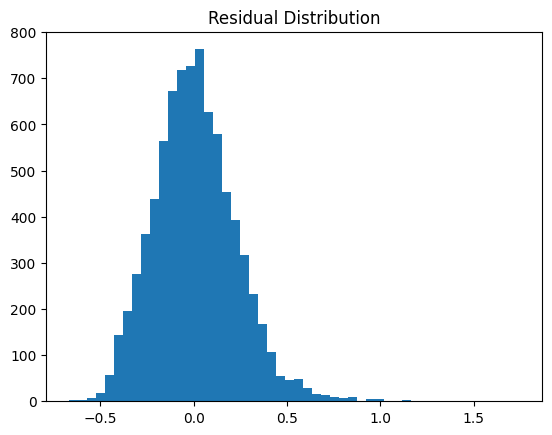

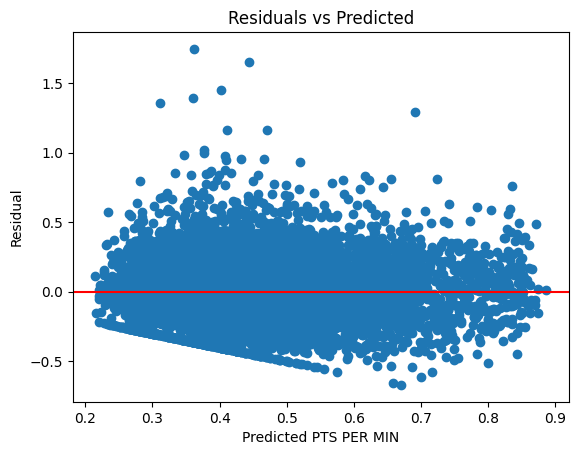

In [28]:
import matplotlib.pyplot as plt


residuals = y_val_ppm - ppm_preds_val

# Distribution of errors
plt.hist(residuals, bins=50)
plt.title('Residual Distribution')
plt.show()

# Are errors random or structured?
plt.scatter(ppm_preds_val, residuals)
plt.axhline(0, color='red')
plt.xlabel('Predicted PTS PER MIN')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.show()

In [29]:
# Use quantile regression to get a range instead of a single number
from sklearn.ensemble import GradientBoostingRegressor

lower = GradientBoostingRegressor(loss='quantile', alpha=0.1)
upper = GradientBoostingRegressor(loss='quantile', alpha=0.9)
mid   = GradientBoostingRegressor(loss='quantile', alpha=0.5)

lower.fit(X_train_ppm, y_train_ppm)
upper.fit(X_train_ppm, y_train_ppm)
mid.fit(X_train_ppm, y_train_ppm)

pred_low  = lower.predict(X_val_ppm)
pred_high = upper.predict(X_val_ppm)
pred_mid  = mid.predict(X_val_ppm)

# Coverage — what % of actuals fall within the interval?
coverage = ((y_val_ppm >= pred_low) & (y_val_ppm <= pred_high)).mean()
print(f"Coverage: {coverage:.2%}")  # want this close to 80%

Coverage: 78.14%


In [30]:
results = X_val_ppm.copy()
results['ACTUAL']    = y_val_ppm.values
results['PREDICTED'] = ppm_preds_val
results['ERROR']     = abs(results['ACTUAL'] - results['PREDICTED'])

# Where is MAE highest?
print(results.groupby('STARTING')['ERROR'].mean())        # starters vs bench

# Error by predicted bucket
results['PRED_BUCKET'] = pd.cut(results['PREDICTED'], bins=[0,15,25,35,48])
results.groupby('PRED_BUCKET')['ERROR'].mean()

STARTING
0    0.190099
1    0.160322
Name: ERROR, dtype: float64


PRED_BUCKET
(0, 15]     0.173328
(15, 25]         NaN
(25, 35]         NaN
(35, 48]         NaN
Name: ERROR, dtype: float64

In [31]:
results = pd.DataFrame({'actual': y_val_ppm.values, 'predicted': ppm_preds_val})

# Bin predictions and compare to actuals
results['bucket'] = pd.cut(results['predicted'], bins=10)
calibration = results.groupby('bucket').agg(
    mean_predicted=('predicted', 'mean'),
    mean_actual=('actual', 'mean'),
    count=('actual', 'count')
)
print(calibration)

                mean_predicted  mean_actual  count
bucket                                            
(0.214, 0.282]        0.264835     0.249908    400
(0.282, 0.349]        0.317564     0.313441   1142
(0.349, 0.416]        0.382279     0.383727   2116
(0.416, 0.484]        0.449369     0.465209   1641
(0.484, 0.551]        0.512727     0.525856   1147
(0.551, 0.618]        0.581181     0.596352    629
(0.618, 0.685]        0.648302     0.667926    526
(0.685, 0.752]        0.714764     0.715308    222
(0.752, 0.819]        0.785098     0.794603    158
(0.819, 0.886]        0.841660     0.911457     94


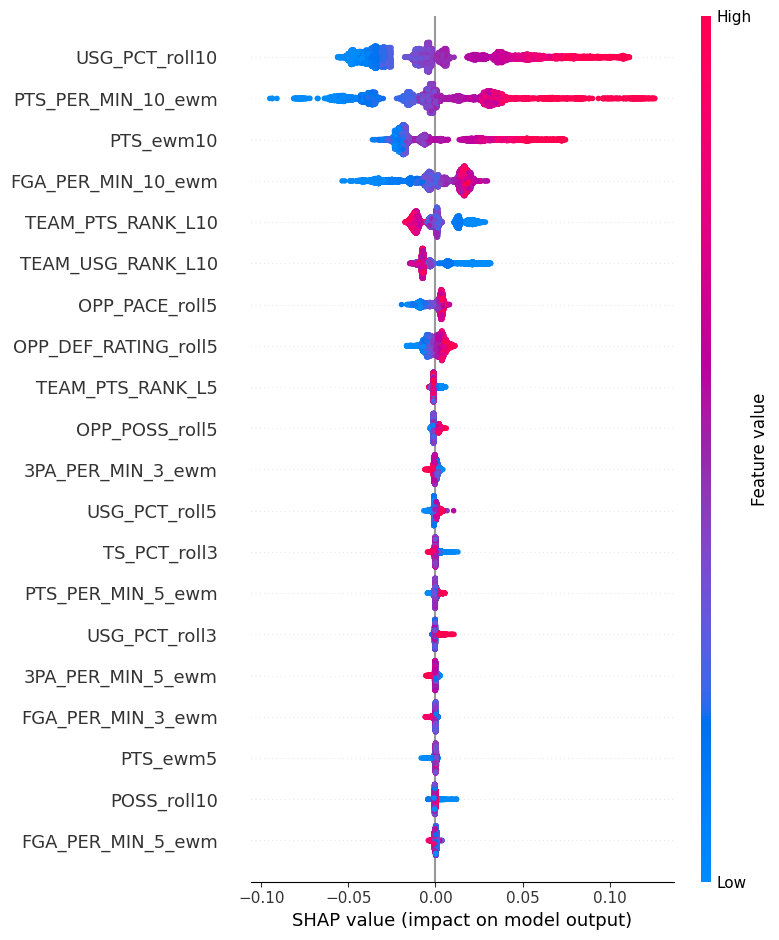

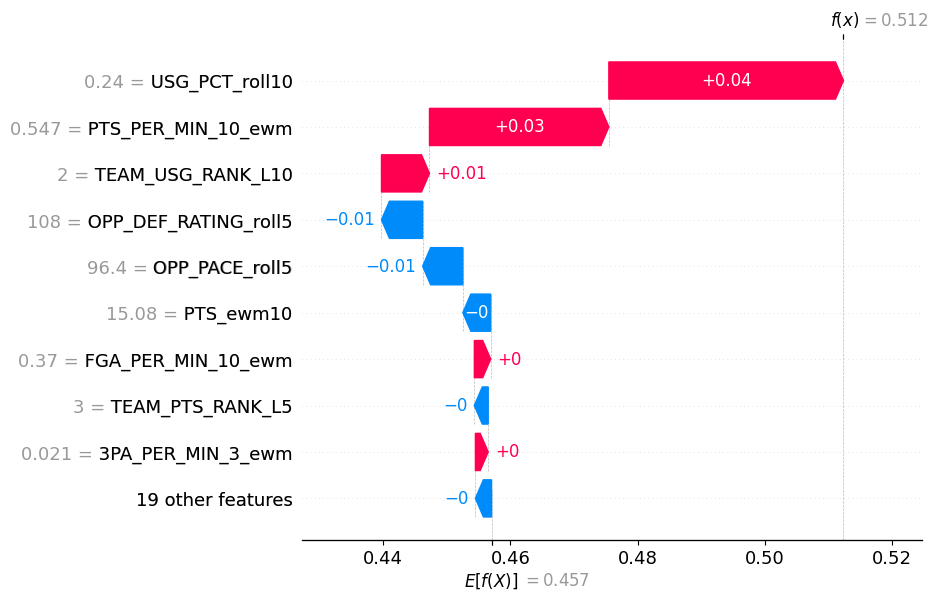

In [14]:
import shap

explainer   = shap.TreeExplainer(xgb_ppm)
shap_values = explainer(X_val_ppm) 

# Global feature importance
shap.summary_plot(shap_values, X_val_ppm, feature_names=PPM_FEATURES)

# Single prediction waterfall
shap.plots.waterfall(shap_values[1154])

In [ ]:
current_date = datetime.today().strftime('%Y-%m-%d')
name = 'LaMelo Ball'

min = min_pipeline(df, name)
ppm = ppm_pipeline(df, name, current_date)

## Playing around with Prop Lines

In [ ]:
today = datetime.today().strftime('%Y%m%d')

def get_latest_file(pattern):
    files = list(Path('data/raw/player_lines').glob(pattern))
    return max(files, key=lambda f: f.stat().st_mtime) if files else None

us_file = get_latest_file('NBA_US_*.csv')
dfs_file = get_latest_file('NBA_DFS_*.csv')

if us_file is None:
    raise ValueError("No US file found")

if dfs_file is None:
    raise ValueError("No DFS file found")

us_df = pd.read_csv(us_file)
lines_dfs = pd.read_csv(dfs_file)

lines_us = us_df[us_df['CATEGORY'] == 'player_points'].copy()


print("US file:", us_file.name)
print("DFS file:", dfs_file.name)
print("DFS latest pull:", lines_dfs['DATA_PULLED_AT'].max())
print("US latest pull:", us_df['DATA_PULLED_AT'].max())

US file: NBA_US_20260328_135457.csv
DFS file: NBA_DFS_20260328_135553.csv
DFS latest pull: 2026-03-28 13:55:53
US latest pull: 2026-03-28 13:54:57


In [ ]:
res = {}

us_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = us_dfs['NAME'].unique()
names = names[:20]

for book_name in names:
    player_name = nameDict[book_name] if book_name in nameDict else book_name

    pdf = df[df['PLAYER_NAME'] == player_name]
    if len(pdf) < 10:
        continue

    min_feats = min_pipeline(df, player_name)   # if your signature takes date
    ppm_feats = ppm_pipeline(df, player_name, current_date)

    if min_feats is None or ppm_feats is None:
        continue

    line_rows = us_dfs[us_dfs['NAME'] == book_name]
    if line_rows.empty:
        continue
    line = float(line_rows['LINE'].iloc[0])

    ppm_arr = np.asarray(ppm_feats, dtype=float).reshape(1, -1)
    min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)

    pred_ppm = xgb_ppm.predict(ppm_arr)
    pred_min = xgb_min.predict(min_arr)
    pred_points = pred_ppm * pred_min

    res[player_name] = {
        "line": line,
        "pred_min": float(pred_min[0]),
        "pred_ppm": float(pred_ppm[0]),
        "project_points": float(pred_points[0]),
    }

pd.DataFrame(res)

,Julius Randle,Rudy Gobert,Donte DiVincenzo,Tobias Harris,Jalen Duren,Kyle Anderson,Daniss Jenkins,Bones Hyland,Joel Embiid,LaMelo Ball,Paul George,Miles Bridges,Tyrese Maxey,VJ Edgecombe,Kon Knueppel,Dominick Barlow,DeMar DeRozan,CJ McCollum,Jalen Johnson
line,24.500000,12.500000,13.500000,13.500000,21.500000,7.500000,15.500000,14.500000,26.500000,20.500000,15.500000,14.500000,24.500000,14.500000,18.500000,6.500000,17.500000,19.500000,24.500000
pred_min,32.366577,31.411369,29.509277,29.065191,28.329842,18.706545,31.055779,22.441807,32.695148,28.426403,32.718716,29.479164,36.054424,34.969273,28.164701,26.164501,30.518492,29.201103,35.000668
pred_ppm,0.613460,0.379155,0.366244,0.437836,0.738909,0.277393,0.451988,0.508328,0.843424,0.777359,0.474572,0.466382,0.775402,0.631988,0.530678,0.301175,0.522984,0.635462,0.624928
project_points,19.855600,11.909785,10.807589,12.725774,20.933186,5.189070,14.036837,11.407798,27.575874,22.097513,15.527397,13.748566,27.956656,22.100159,14.946383,7.880100,15.960670,18.556189,21.872913


In [ ]:
ppm_arr = np.asarray(ppm, dtype=float).reshape(1, -1)   # (1, 23)
ppmPreds = xgb_ppm.predict(ppm_arr)
min_arr = np.asarray(min, dtype=float).reshape(1, -1)   # (1, 23)
minPreds = xgb_min.predict(min_arr)
predicted_points = ppmPreds * minPreds
print(f"Points Per Min: {ppmPreds}")
print(f"Minutes: {minPreds}")
print(f"Predicted Points: {predicted_points}")

Points Per Min: [0.7773588]
Minutes: [28.426403]
Predicted Points: [22.097513]


LaMelo Ball | Pred=24.50 | Median=24.47 | Line=20.50 | Std=6.40
Over 73.38% | Under 26.62%
Fair Over odds: -276, Fair Under odds: 276


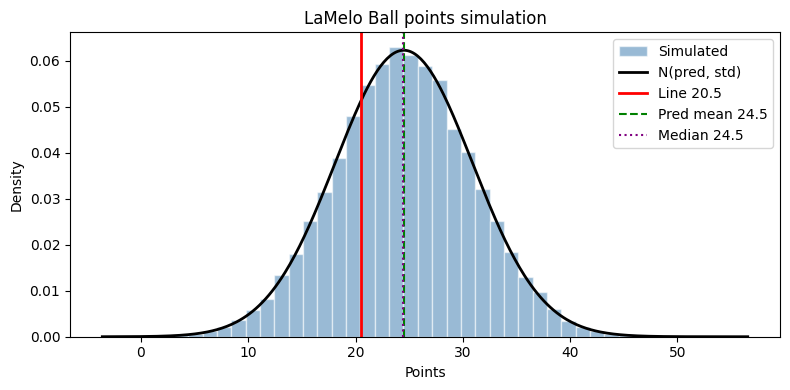

In [ ]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

player = "LaMelo Ball"
line = us_dfs[us_dfs['NAME'] == player]['LINE'].iloc[0]                        # <- your model prediction

# Option A: historical game-to-game volatility
pdf = df[df["PLAYER_NAME"] == player].sort_values("GAME_DATE")
std = float(pdf["PTS"].tail(20).std())

# Guardrail if std too small / NaN
if not np.isfinite(std) or std < 1.0:
    std = 4.5

rng = np.random.default_rng(42)
samples = rng.normal(loc=predicted_points, scale=std, size=50_000)
median_pts = float(np.median(samples))

over_prob = (samples > line).mean()
under_prob = (samples < line).mean()

print(f"{player} | Pred={predicted_points:.2f} | Median={median_pts:.2f} | Line={line:.2f} | Std={std:.2f}")
print(f"Over {over_prob:.2%} | Under {under_prob:.2%}")

# Optional: fair odds
p_over = np.clip(over_prob, 1e-6, 1 - 1e-6)
p_under = np.clip(under_prob, 1e-6, 1 - 1e-6)
fair_over_american = -100 * p_over/(1-p_over) if p_over >= 0.5 else 100 * (1-p_over)/p_over
fair_under_american = -100 * p_under/(1-p_under) if p_under >= 0.5 else 100 * (1-p_under)/p_under
print(f"Fair Over odds: {fair_over_american:.0f}, Fair Under odds: {fair_under_american:.0f}")

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(samples, bins=45, density=True, alpha=0.55, color="steelblue", edgecolor="white", label="Simulated")
xs = np.linspace(samples.min(), samples.max(), 400)
ax.plot(xs, norm.pdf(xs, loc=predicted_points, scale=std), color="black", lw=2, label="N(pred, std)")
ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(predicted_points, color="green", ls="--", lw=1.5, label=f"Pred mean {predicted_points:.1f}")
ax.axvline(median_pts, color="purple", ls=":", lw=1.5, label=f"Median {median_pts:.1f}")
ax.set_xlabel("Points")
ax.set_ylabel("Density")
ax.set_title(f"{player} points simulation")
ax.legend()
plt.tight_layout()
plt.show()

Predicted: 24.50 | Hist mean: 22.10 | n_games: 10
Over 70.08% | under 29.92%
Sim mean: 24.09 | Sim median: 22.0 | Sim std: 5.38 | Line: 20.50


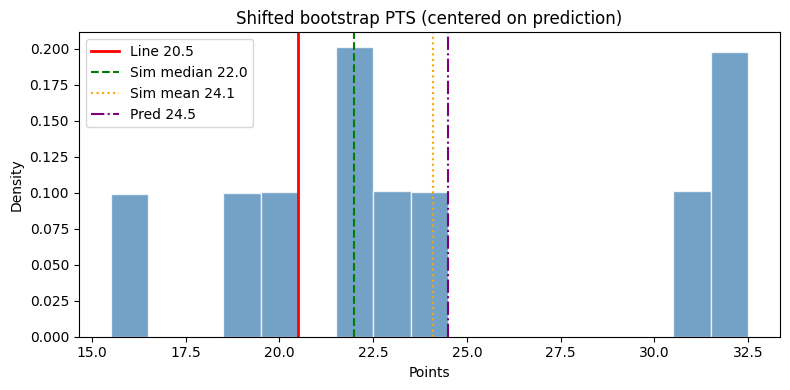

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
        # LeBron id
n_sims = 100_000
rng = np.random.default_rng()

# --- history for bootstrap (must come from game log data with PTS) ---
pdf = df[df["PLAYER_NAME"] == player].sort_values("GAME_DATE")
pts_history = pd.to_numeric(pdf["PTS"].tail(10), errors="coerce").dropna().values
if len(pts_history) < 3:
    raise ValueError("Need a few games in pts_history for bootstrap.")

# Shift bootstrapped historical samples so mean == predicted_points
hist_mean = float(np.mean(pts_history))
samples = rng.choice(pts_history, size=n_sims, replace=True) + (predicted_points - hist_mean)

# Sportsbook PTS are integers
samples_int = np.clip(np.rint(samples), 0, None).astype(int)

# Over/under (works for .5 lines: e.g., over 18.5 => 19+)
over_prob = (samples_int > line).mean()
under_prob = (samples_int < line).mean()

print(f"Predicted: {predicted_points:.2f} | Hist mean: {hist_mean:.2f} | n_games: {len(pts_history)}")
print(f"Over {over_prob:.2%} | under {under_prob:.2%}")
print(
    f"Sim mean: {samples_int.mean():.2f} | Sim median: {np.median(samples_int):.1f} | "
    f"Sim std: {samples_int.std(ddof=1):.2f} | Line: {line:.2f}"
)

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(samples_int.min() - 0.5, samples_int.max() + 1.5, 1)
ax.hist(samples_int, bins=bins, density=True, alpha=0.75, color="steelblue", edgecolor="white")

ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(np.median(samples_int), color="green", ls="--", lw=1.5, label=f"Sim median {np.median(samples_int):.1f}")
ax.axvline(np.mean(samples_int), color="orange", ls=":", lw=1.5, label=f"Sim mean {np.mean(samples_int):.1f}")
ax.axvline(predicted_points, color="purple", ls="-.", lw=1.5, label=f"Pred {predicted_points:.1f}")

ax.set_xlabel("Points")
ax.set_ylabel("Density")
ax.set_title("Shifted bootstrap PTS (centered on prediction)")
ax.legend()
plt.tight_layout()
plt.show()

Negative binomial (mean from model, variance from L10 history)
  fitted n=76.7365, p=0.75799
  target mu=24.50, target var=32.32
  sim mean=24.50, sim var=32.89
Over 75.01% | under 24.99%


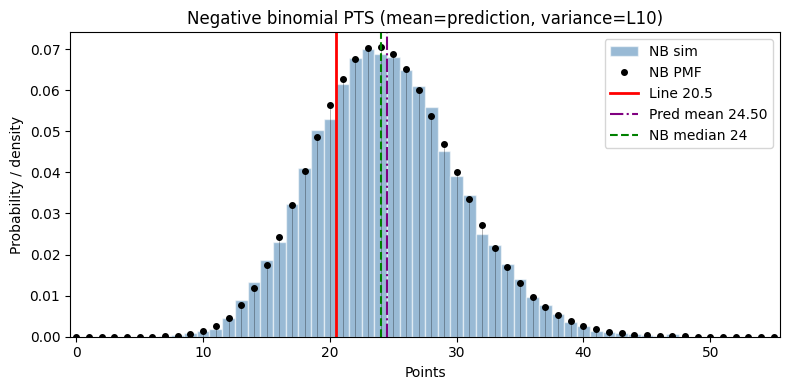

In [ ]:
from scipy.stats import nbinom
import numpy as np
import matplotlib.pyplot as plt

# --- presets ---
player_id = df[df['PLAYER_NAME'] == player]['PLAYER_ID'].iloc[0]
n_sims = 10_000

# --- history (for variance / dispersion) ---
pdf = df[df["PLAYER_ID"] == player_id].sort_values("GAME_DATE")
pts_history = pd.to_numeric(pdf["PTS"].tail(10), errors="coerce").dropna().values
if len(pts_history) < 3:
    raise ValueError("Need a few games in pts_history for NB fit.")

# Use model prediction as mean, historical variance as uncertainty
mu = float(predicted_points)
hist_var = float(np.var(pts_history, ddof=1)) if len(pts_history) > 1 else mu

# Ensure NB is valid: variance must be > mean
var = max(hist_var, mu * 1.001)

# scipy NB parameterization:
# mean = n*(1-p)/p, var = n*(1-p)/p^2
# => p = mu/var, n = mu*p/(1-p)
p_nb = mu / var
n_nb = max(mu * p_nb / (1.0 - p_nb), 1e-6)

rng = np.random.default_rng(42)
samples_nb = nbinom.rvs(n_nb, p_nb, size=n_sims, random_state=rng)

over_prob = (samples_nb > line).mean()
under_prob = (samples_nb < line).mean()
push_prob = (samples_nb == line).mean() if float(line).is_integer() else 0.0

print("Negative binomial (mean from model, variance from L10 history)")
print(f"  fitted n={n_nb:.4f}, p={p_nb:.5f}")
print(f"  target mu={mu:.2f}, target var={var:.2f}")
print(f"  sim mean={samples_nb.mean():.2f}, sim var={samples_nb.var(ddof=1):.2f}")
print(f"Over {over_prob:.2%} | under {under_prob:.2%}" + (f" | push {push_prob:.2%}" if push_prob > 0 else ""))

# --- Visual ---
k_max = int(max(samples_nb.max(), line) + 8)
ks = np.arange(0, k_max + 1)
pmf = nbinom.pmf(ks, n_nb, p_nb)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(-0.5, k_max + 1.5, 1)
ax.hist(samples_nb, bins=bins, density=True, alpha=0.55, color="steelblue", edgecolor="white", label="NB sim")
ax.plot(ks, pmf, "ko", ms=4, label="NB PMF")
ax.vlines(ks, 0, pmf, colors="black", lw=0.6, alpha=0.35)
ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(mu, color="purple", ls="-.", lw=1.5, label=f"Pred mean {mu:.2f}")
ax.axvline(nbinom.median(n_nb, p_nb), color="green", ls="--", lw=1.5, label=f"NB median {nbinom.median(n_nb, p_nb):.0f}")
ax.set_xlabel("Points")
ax.set_ylabel("Probability / density")
ax.set_title("Negative binomial PTS (mean=prediction, variance=L10)")
ax.set_xlim(-0.5, k_max + 0.5)
ax.legend()
plt.tight_layout()
plt.show()